# Titanic EDA & Machine Learning Project

## هدف پروژه
در این نوت‌بوک:
- بررسی اولیه داده‌ها
- تحلیل اکتشافی (EDA)
- مصورسازی حرفه‌ای
- بررسی ارتباط ویژگی‌ها با بقا
- Feature Engineering ساده
- آموزش چند مدل Machine Learning
- مقایسه نتایج مدل‌ها

---


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

plt.rcParams['figure.figsize'] = (8,5)

data = pd.read_csv("titanic.csv")

print("Shape:", data.shape)
data.head()


Shape: (887, 8)


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


## 1. بررسی اولیه داده‌ها

In [2]:
data.info()

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicated Rows:", data.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    object 
 3   Sex                      887 non-null    object 
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB

Missing Values:
Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64

Duplicated Rows: 0


In [3]:
data.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Survived,887.0,NaN,NaN,NaN,0.385569,0.487004,0.0,0.0,0.0,1.0,1.0
Pclass,887.0,NaN,NaN,NaN,2.305524,0.836662,1.0,2.0,3.0,3.0,3.0
Name,887,887,Mr. Patrick Dooley,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,887,2,male,573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,887.0,NaN,NaN,NaN,29.471443,14.121908,0.42,20.25,28.0,38.0,80.0
Siblings/Spouses Aboard,887.0,NaN,NaN,NaN,0.525366,1.104669,0.0,0.0,0.0,1.0,8.0
Parents/Children Aboard,887.0,NaN,NaN,NaN,0.383315,0.807466,0.0,0.0,0.0,0.0,6.0
Fare,887.0,NaN,NaN,NaN,32.30542,49.78204,0.0,7.925,14.4542,31.1375,512.3292


## 2. تحلیل متغیر هدف (Survived)

Survival Rate: 38.56%


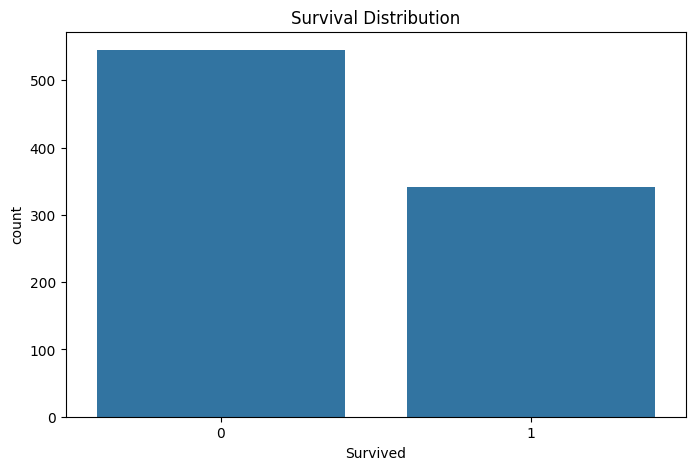

In [4]:
survival_rate = data['Survived'].mean()*100

print(f"Survival Rate: {survival_rate:.2f}%")

sns.countplot(data=data, x='Survived')
plt.title('Survival Distribution')
plt.show()


## 3. تحلیل ویژگی‌های عددی

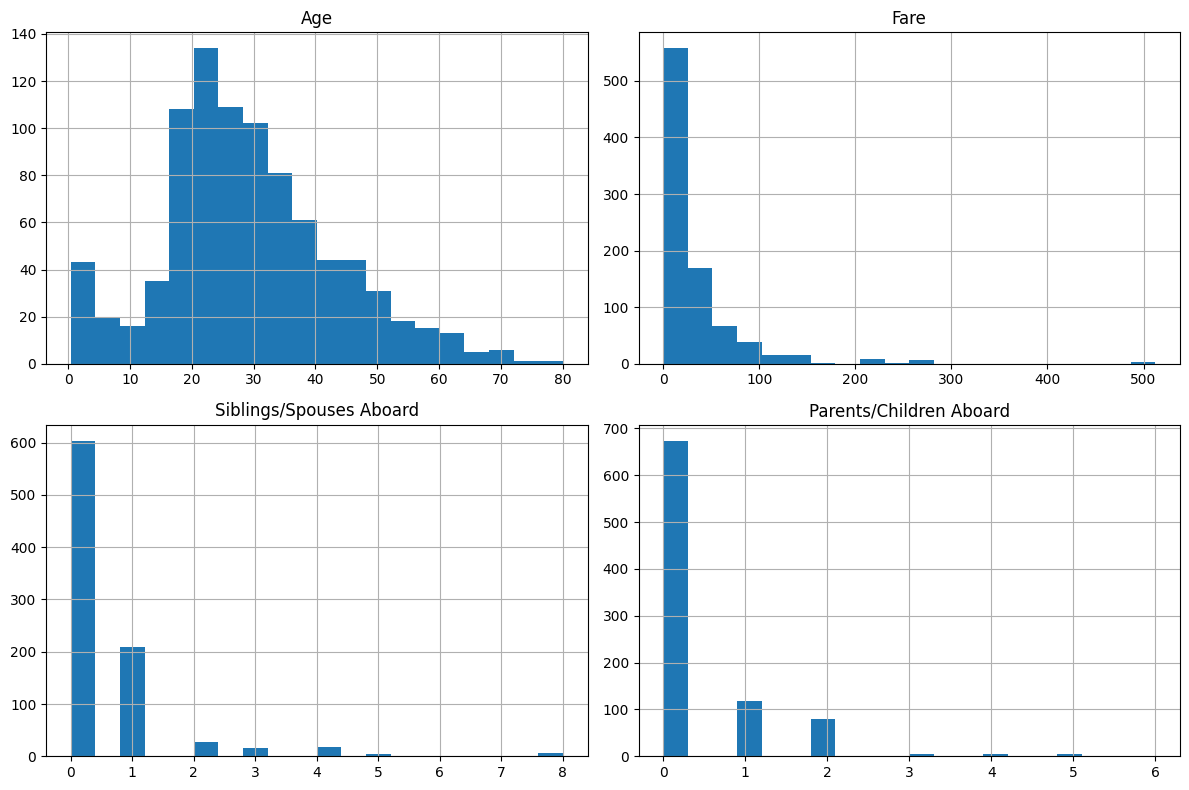

In [5]:
numeric_cols = [
    'Age',
    'Fare',
    'Siblings/Spouses Aboard',
    'Parents/Children Aboard'
]

data[numeric_cols].hist(bins=20, figsize=(12,8))
plt.tight_layout()
plt.show()


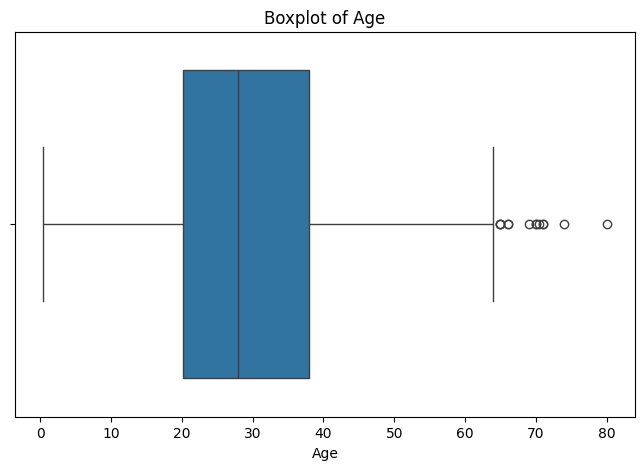

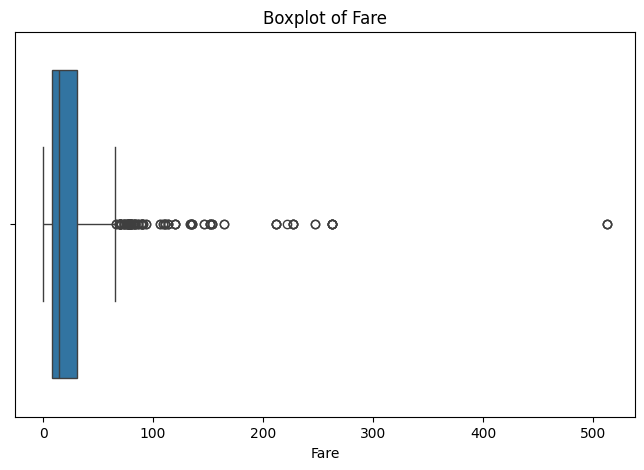

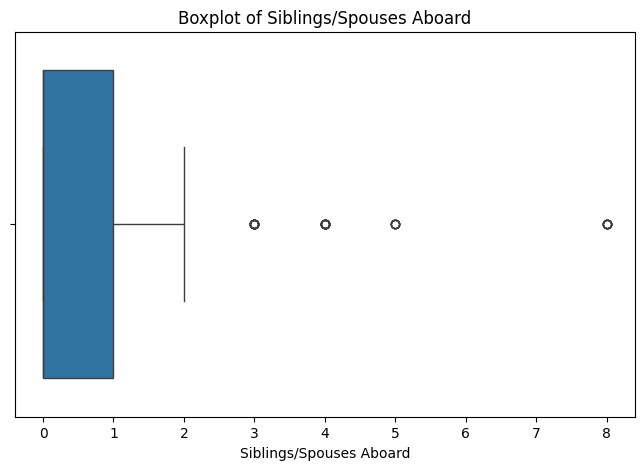

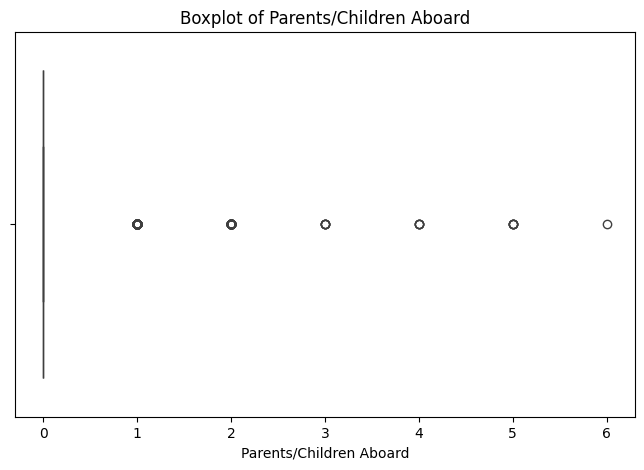

In [6]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


## 4. تحلیل ویژگی‌های دسته‌ای

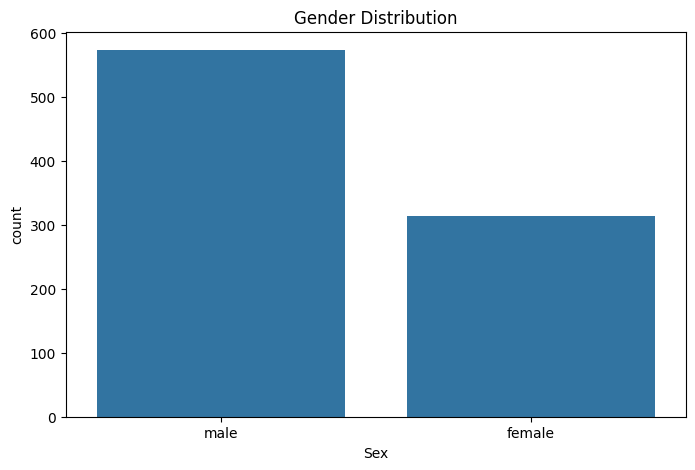

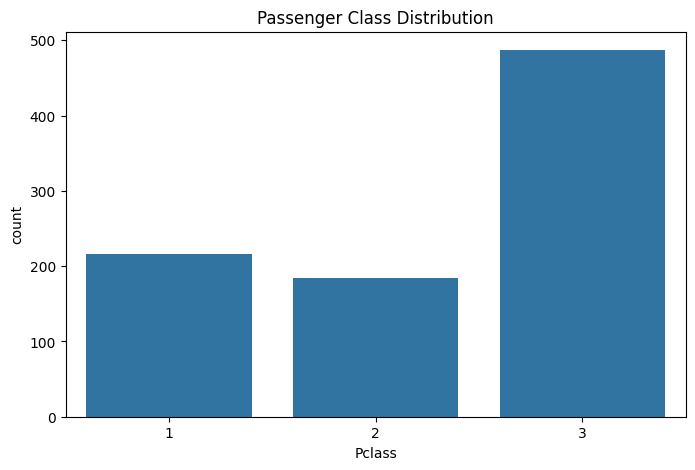

In [7]:
sns.countplot(data=data, x='Sex')
plt.title('Gender Distribution')
plt.show()

sns.countplot(data=data, x='Pclass')
plt.title('Passenger Class Distribution')
plt.show()


## 5. رابطه ویژگی‌ها با بقا

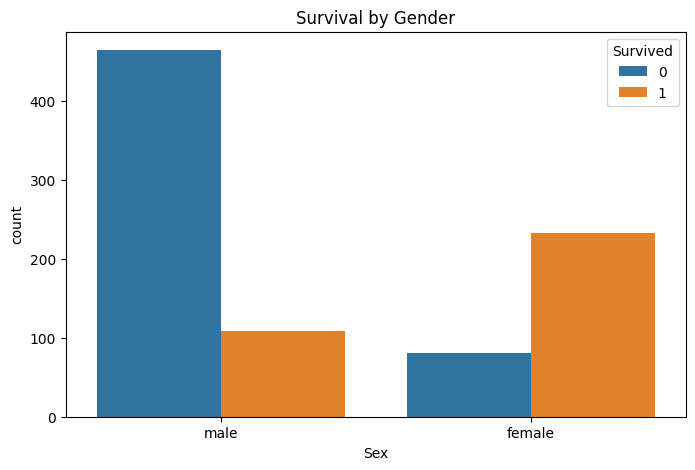

Survived,0,1
Sex,,
female,25.796178,74.203822
male,80.977312,19.022688


In [8]:
sns.countplot(data=data, x='Sex', hue='Survived')
plt.title('Survival by Gender')
plt.show()

pd.crosstab(data['Sex'], data['Survived'], normalize='index')*100


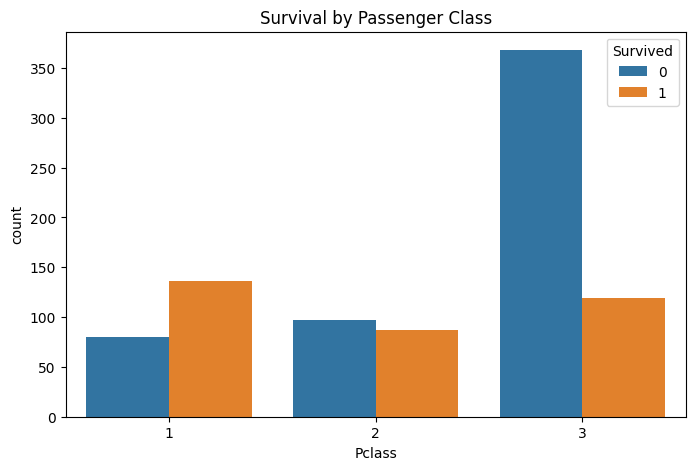

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.564682,24.435318


In [9]:
sns.countplot(data=data, x='Pclass', hue='Survived')
plt.title('Survival by Passenger Class')
plt.show()

pd.crosstab(data['Pclass'], data['Survived'], normalize='index')*100


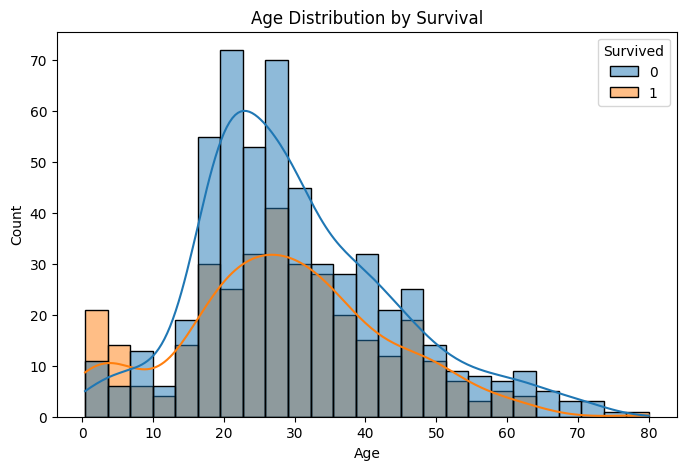

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x='Age',
    hue='Survived',
    bins=25,
    kde=True
)

plt.title('Age Distribution by Survival')
plt.show()


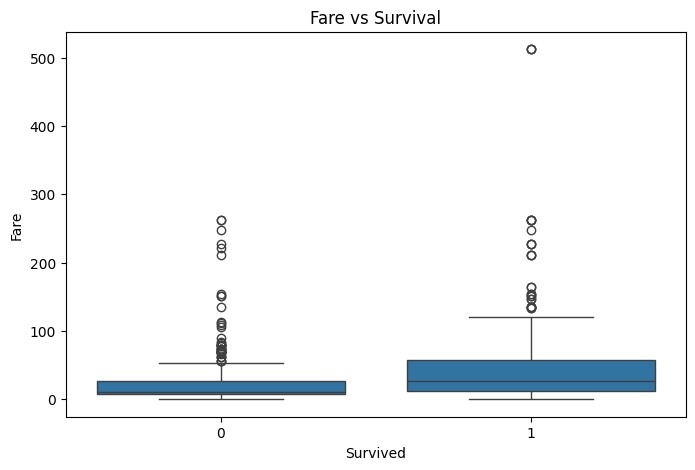

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=data,
    x='Survived',
    y='Fare'
)

plt.title('Fare vs Survival')
plt.show()


## 6. Correlation Analysis

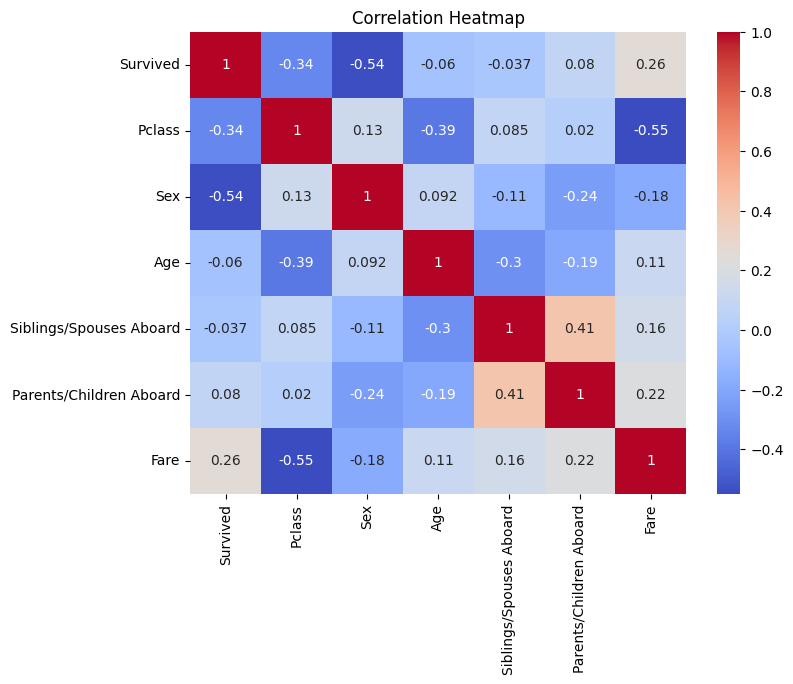

In [12]:
temp = data.copy()

le = LabelEncoder()
temp['Sex'] = le.fit_transform(temp['Sex'])

corr = temp.drop(columns=['Name']).corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## 7. Feature Engineering

In [13]:
df = data.copy()

df['Family_Size'] = (
    df['Siblings/Spouses Aboard']
    + df['Parents/Children Aboard']
    + 1
)

df['Sex'] = LabelEncoder().fit_transform(df['Sex'])

df.head()


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family_Size
0,0,3,Mr. Owen Harris Braund,1,22.0,1,0,7.2500,2
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,0,38.0,1,0,71.2833,2
2,1,3,Miss. Laina Heikkinen,0,26.0,0,0,7.9250,1
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,0,35.0,1,0,53.1000,2
4,0,3,Mr. William Henry Allen,1,35.0,0,0,8.0500,1


## 8. آماده‌سازی داده برای مدل‌سازی

In [14]:
X = df.drop(columns=['Survived', 'Name'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)


(709, 7) (178, 7)


## 9. Logistic Regression

In [15]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))


Accuracy: 0.7752808988764045
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       109
           1       0.72      0.68      0.70        69

    accuracy                           0.78       178
   macro avg       0.76      0.76      0.76       178
weighted avg       0.77      0.78      0.77       178



## 10. Decision Tree

In [16]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_dt))
print(classification_report(y_test, pred_dt))


Accuracy: 0.8033707865168539
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       109
           1       0.80      0.65      0.72        69

    accuracy                           0.80       178
   macro avg       0.80      0.78      0.78       178
weighted avg       0.80      0.80      0.80       178



## 11. Random Forest

In [17]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))


Accuracy: 0.7752808988764045
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       109
           1       0.71      0.71      0.71        69

    accuracy                           0.78       178
   macro avg       0.76      0.76      0.76       178
weighted avg       0.78      0.78      0.78       178



## 12. KNN

In [18]:
knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_knn))
print(classification_report(y_test, pred_knn))


Accuracy: 0.702247191011236
              precision    recall  f1-score   support

           0       0.75      0.78      0.76       109
           1       0.62      0.58      0.60        69

    accuracy                           0.70       178
   macro avg       0.69      0.68      0.68       178
weighted avg       0.70      0.70      0.70       178



## 13. مقایسه مدل‌ها

In [19]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],
    'Accuracy':[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_knn)
    ]
})

results = results.sort_values(
    by='Accuracy',
    ascending=False
)

results


,Model,Accuracy
1,Decision Tree,0.803371
0,Logistic Regression,0.775281
2,Random Forest,0.775281
3,KNN,0.702247


In [ ]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=results,
    x='Accuracy',
    y='Model'
)

plt.title('Model Comparison')
plt.show()


# نتیجه‌گیری

مهم‌ترین عوامل اثرگذار بر بقا:
- جنسیت
- کلاس مسافر
- کرایه سفر (Fare)
- سن
- اندازه خانواده

بهترین مدل را از جدول بالا انتخاب کنید و در ادامه می‌توانید:
- Hyperparameter Tuning
- Cross Validation
- Feature Selection
- Ensemble Methods

را نیز اضافه کنید.
